In [1]:
import ROOT

Welcome to JupyROOT 6.26/10


In [2]:
# Open ROOT file
# file_path = "../preselection/parkingDoubleMuonLowMass/2023/PDMLM0_mm_2023D_v1_HLT_Dimuon0_Jpsi3p5_Muon2_v9.root"
# file_path = "../preselection/parkingDoubleMuonLowMass/2023/allTrig/crab_TTree_136TeV_PDMLM0_mm_2023D_v1.root"
file_path = "../preselection/parkingDoubleMuonLowMass/2024/crab_TTree_136TeV_PDMLM0_mm_2023D_v2.root"
file = ROOT.TFile.Open(file_path)
# tree = file.Get("tree")  # Replace with the correct tree name
tree = file.Get("ntuple")  # Replace with the correct tree name
tree.GetEntries()

25135764

In [3]:
tree.Show()

======> EVENT:-1
 Run             = 0
 LumiBlock       = 0
 Event           = 0
 B_J1_mass       = 0
 B_J1_pt         = 0
 B_Mu1_pt        = 0
 B_Mu2_pt        = 0


In [4]:
J_Mass = ROOT.RooRealVar("B_J1_mass", "J/\psi Mass", 2.6, 3.6, "GeV")
# LS = ROOT.RooRealVar("LumiBlock", "LumiBlock", 800, 850)
data = ROOT.RooDataSet("data", "dataset", tree, ROOT.RooArgSet(J_Mass))

[#1] INFO:DataHandling -- RooAbsReal::attachToTree(B_J1_mass) TTree Float_t branch B_J1_mass will be converted to double precision.


In [5]:
# Define Gaussian signal model
mean = ROOT.RooRealVar("mean", "Mean of Gaussians", 3.1, 3.0, 3.2)
sigma1 = ROOT.RooRealVar("sigma1", "Width of Gaussian 1", 0.001, 0.005, 0.1)
sigma2 = ROOT.RooRealVar("sigma2", "Width of Gaussian 2", 0.05, 0.005, 0.1)
gauss1 = ROOT.RooGaussian("gauss1", "Gaussian 1", J_Mass, mean, sigma1)
gauss2 = ROOT.RooGaussian("gauss2", "Gaussian 2", J_Mass, mean, sigma2)
frac = ROOT.RooRealVar("frac", "Fraction of Gauss1", 0.5, 0.0, 1.0)
signal = ROOT.RooAddPdf("signal", "Double Gaussian", ROOT.RooArgList(gauss1, gauss2), ROOT.RooArgList(frac))

# # Define mass and resolution parameters
# mean = ROOT.RooRealVar("mean", "Mean of the resonance", 3.1, 3.0, 3.2)   # Center of the peak
# width = ROOT.RooRealVar("width", "Breit-Wigner width", 0.01, 0.001, 0.1) # Natural width (resonance width)
# sigma = ROOT.RooRealVar("sigma", "Gaussian resolution", 0.01, 0.001, 0.1) # Detector resolution

# # Define Voigtian signal model (Breit-Wigner convoluted with Gaussian)
# signal = ROOT.RooVoigtian("signal", "Voigtian Signal", J_Mass, mean, width, sigma)

# Define background model (2nd degree polynomial)
a0 = ROOT.RooRealVar("a0", "a0", 0.0, -1.0, 1.0)
a1 = ROOT.RooRealVar("a1", "a1", 0.0, -1.0, 1.0)
background = ROOT.RooPolynomial("background", "polynomial", J_Mass, ROOT.RooArgList(a0, a1))

# Combine signal and background
sigFrac = ROOT.RooRealVar("sigFrac", "Number of signal events", 0.5, 0.0, 1.0)
model = ROOT.RooAddPdf("model", "Signal + Background", ROOT.RooArgList(signal, background), ROOT.RooArgList(sigFrac))

In [6]:
# Combine signal and background
sigFrac = ROOT.RooRealVar("sigFrac", "Number of signal events", 0.5, 0.0, 1.0)
model = ROOT.RooAddPdf("model", "Signal + Background", ROOT.RooArgList(signal, background), ROOT.RooArgList(sigFrac))

In [7]:
# Perform fit
result = model.fitTo(data, ROOT.RooFit.Save())

[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (gauss1,gauss2,background)
 **********
 **    1 **SET PRINT           1
 **********
 **********
 **    2 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 a0           0.00000e+00  2.00000e-01   -1.00000e+00  1.00000e+00
     2 a1           0.00000e+00  2.00000e-01   -1.00000e+00  1.00000e+00
     3 frac         5.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     4 mean         3.10000e+00  2.00000e-02    3.00000e+00  3.20000e+00
     5 sigFrac      5.00000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     6 sigma1       5.00000e-03  9.50000e-03    5.00000e-03  1.00000e-01
 MINUIT WARNING IN PARAM DEF
 ============== STARTING VALUE IS AT LIMIT.
 MINUIT WARNING IN PARAMETR
 ============== VARIABLE6 IS AT ITS LOWER ALLOWED LIMIT.
 MIN

[#1] INFO:Plotting -- RooAbsPdf::plotOn(model) directly selected PDF components: (background)
[#1] INFO:Plotting -- RooAbsPdf::plotOn(model) indirectly selected PDF components: ()
[#1] INFO:Plotting -- RooAbsPdf::plotOn(model) directly selected PDF components: (signal)
[#1] INFO:Plotting -- RooAbsPdf::plotOn(model) indirectly selected PDF components: (gauss1,gauss2)


Info in <TCanvas::Print>: png file fit_result.png has been created


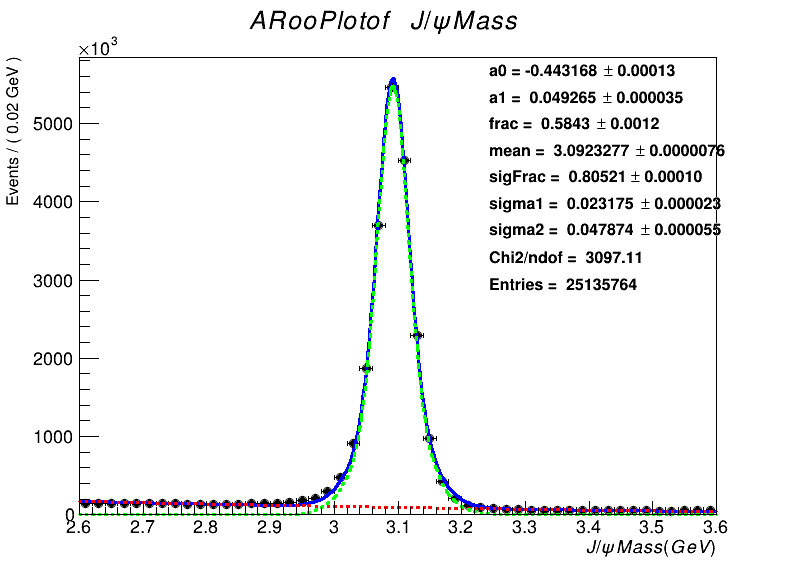

In [8]:
# Plot results
c1 = ROOT.TCanvas("c1", "Fit", 800, 600)
frame = J_Mass.frame()
data.plotOn(frame, ROOT.RooFit.Name('dataset'), ROOT.RooFit.Binning(50))
model.plotOn(frame, ROOT.RooFit.Name('model'))
model.plotOn(frame, ROOT.RooFit.Components("background"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kRed))
model.plotOn(frame, ROOT.RooFit.Components("signal"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen))

chi2 = frame.chiSquare("model", "dataset", 7)

# Stat box
model.paramOn(frame, ROOT.RooFit.Layout(0.6, 0.9, 0.9))
frame.getAttText().SetTextSize(0.03)
frame.GetYaxis().SetTitleSize(0.03)
frame.GetYaxis().SetTitleOffset(1.7)
pt = frame.findObject("model_paramBox")
pt.AddText(ROOT.Form(f"Chi2/ndof =  {chi2:.2f}"))
pt.AddText(ROOT.Form("Entries =  {0:.0f}".format(data.numEntries())))

frame.Draw()
c1.SaveAs("fit_result.png")

# Keep the canvas open
c1.Draw()

In [9]:
# # Open a ROOT file for writing
# output_file = ROOT.TFile("Charmonium_Run304144_LS800_850_HLT_Dimuon0_Jpsi3p5_Muon2_v4.root", "RECREATE")
# tree = ROOT.TTree("ntuple", "TTree from RooDataSet")
# var = data.get().find("B_J1_mass")  # Adjust variable name if needed

# # Create a float branch
# b_mass = ROOT.std.vector('float')()
# tree.Branch("B_J1_mass", b_mass)

# # Loop over the dataset and fill the tree
# for i in range(int(data.numEntries())):
#     event = data.get(i)  # Get the i-th entry
#     b_mass.clear()
#     b_mass.push_back(event.getRealValue("B_J1_mass"))
#     tree.Fill()

# # Write and close the file
# tree.Write()
# output_file.Close()

# print("TTree successfully saved")